In [ ]:
"""
BUSINESS PROBLEM

The e-commerce platform is experiencing revenue leakage despite strong customer traffic and order volume.

Key Issue:
A significant number of orders are not successfully completed or delivered, leading to loss of potential revenue.

Objectives:
1. Analyze the order funnel to identify drop-off stages
2. Quantify revenue loss from unsuccessful orders
3. Identify key factors contributing to order failure (e.g., payment issues, cancellations)
4. Segment customers to understand revenue contribution
5. Provide data-driven recommendations to improve conversion and recover lost revenue
"""

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:

orders = pd.read_csv("D:/DataAnalytics/olist/olist_orders_dataset.csv")
items = pd.read_csv("D:/DataAnalytics/olist/olist_order_items_dataset.csv")
payments = pd.read_csv("D:/DataAnalytics/olist/olist_order_payments_dataset.csv")
customers = pd.read_csv("D:/DataAnalytics/olist/olist_customers_dataset.csv")


In [11]:
print("orders:",orders.shape)
print("items:",items.shape)
print("payments:",payments.shape)
print("customers:",customers.shape)

orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
customers: (99441, 5)


In [16]:
orders.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [13]:
items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [14]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [15]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [17]:
df=orders.merge(customers, on='customer_id', how='left')\
         .merge(items, on='order_id',how='left')\
         .merge(payments, on='order_id',how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12


In [18]:
df['revenue']=df['price']+df['freight_value']

In [19]:
df.shape

(118434, 23)

In [20]:
df[['order_id','customer_id','payment_type','revenue']].head()

,order_id,customer_id,payment_type,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,credit_card,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,boleto,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,credit_card,179.12


In [21]:
order_df = df.groupby('order_id').agg({
    'customer_id': 'first',
    'order_status': 'first',
    'payment_type': 'first',
    'revenue': 'sum'
}).reset_index()

In [22]:
order_df.shape

(99441, 5)

In [23]:
order_df.head()

,order_id,customer_id,order_status,payment_type,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,credit_card,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,credit_card,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,credit_card,216.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,credit_card,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,credit_card,218.04


In [25]:
funnel=order_df['order_status'].value_counts()
funnel

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [27]:
total_orders=order_df['order_id'].nunique()
delivered_orders=order_df[order_df['order_status']=='delivered']['order_id'].nunique()
conversion_rate=delivered_orders / total_orders
print("conversion_rate:",round(conversion_rate*100,2),"%")

conversion_rate: 97.02 %


In [ ]:
"""
KEY INSIGHT:

- ~97% of orders are successfully delivered
- ~3% of orders fail (cancelled, unavailable, etc.)
- Even a small failure rate leads to significant revenue loss

BUSINESS IMPACT:

Improving failed orders by even 1–2% can recover substantial revenue
"""

In [31]:
failed_orders=order_df[order_df['order_status']!= 'delivered']
revenue_loss=failed_orders['revenue'].sum()
total_revenue=order_df['revenue'].sum()
print("Total_revenue:",round(total_revenue,2))
print("Revenue_loss:",round(revenue_loss,2))
print("Revenue_loss %:",round((revenue_loss/total_revenue)*100,2),"%")

Total_revenue: 16566687.31
Revenue_loss: 452524.79
Revenue_loss %: 2.73 %


In [ ]:
"""
KEY INSIGHT:

- Total revenue generated: ~₹1.65 Cr
- Revenue loss due to failed orders: ~₹4.52 Lakhs
- Around 2.73% of total revenue is lost due to order failures

BUSINESS IMPACT:

Even a small failure rate (~3%) results in significant revenue loss.

Reducing order failures by even 1% can recover lakhs in revenue.
"""

In [33]:
payment_failure=order_df[order_df['order_status'] != 'delivered']
payment_analysis=payment_failure.groupby('payment_type')['revenue'].sum().sort_values(ascending=False)
payment_analysis

payment_type
credit_card    339596.43
boleto          72307.58
voucher         33936.17
debit_card       6684.61
not_defined         0.00
Name: revenue, dtype: float64

In [34]:
payment_analysis_pct=(payment_analysis/revenue_loss)*100
payment_analysis_pct

payment_type
credit_card    75.044824
boleto         15.978700
voucher         7.499295
debit_card      1.477181
not_defined     0.000000
Name: revenue, dtype: float64

In [ ]:
"""
KEY INSIGHT:

- Credit card payments contribute ~75% of total revenue loss
- This is the dominant failure source in the system
- Other payment methods have significantly lower impact

BUSINESS INTERPRETATION:

Since credit card is the most used payment method, even small failure rates
lead to large revenue loss.

This indicates potential issues in:
- Payment gateway reliability
- Transaction failures
- Authorization issues

RECOMMENDATION:

1. Optimize credit card payment processing
2. Add fallback payment options
3. Improve retry mechanisms for failed transactions
"""

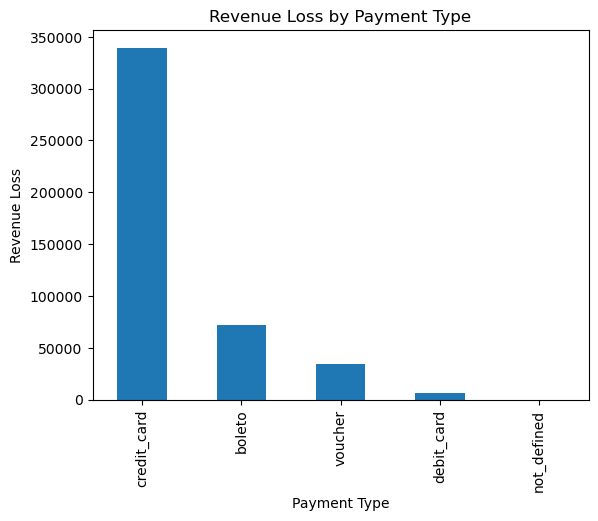

In [35]:
payment_analysis.plot(kind='bar')
plt.title("Revenue Loss by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue Loss")
plt.show()

In [ ]:
"""
INSIGHTS: REVENUE LOSS BY PAYMENT TYPE

- Credit card contributes the highest revenue loss (~₹3.4 Lakhs), accounting for ~75% of total loss
- This indicates that credit card failures are the primary driver of revenue leakage

- Boleto contributes ~₹72K (~16%) of the total revenue loss
- Voucher and debit card contribute minimal revenue loss

INTERPRETATION:

- Revenue loss is highly concentrated in one payment method (credit card)
- Even small failure rates in high-usage payment methods lead to significant financial impact
"""

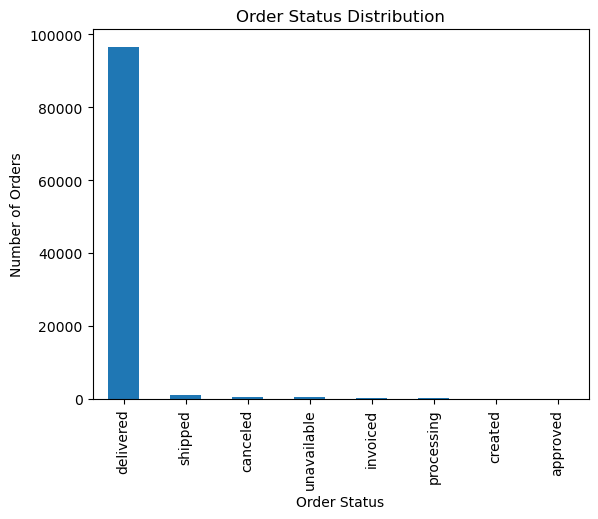

In [37]:
order_df['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
"""
INSIGHTS: ORDER STATUS DISTRIBUTION

- The majority of orders are successfully delivered (~97%)
- This indicates a high overall system success rate

- Failed orders (cancelled, unavailable, etc.) account for ~3% of total orders
- Although small in percentage, they still contribute to noticeable revenue loss

- Intermediate statuses (processing, shipped, invoiced) are minimal
- Most orders quickly reach a final state (delivered or failed)

INTERPRETATION:

- The system is operationally efficient, but small failure rates still impact revenue
"""

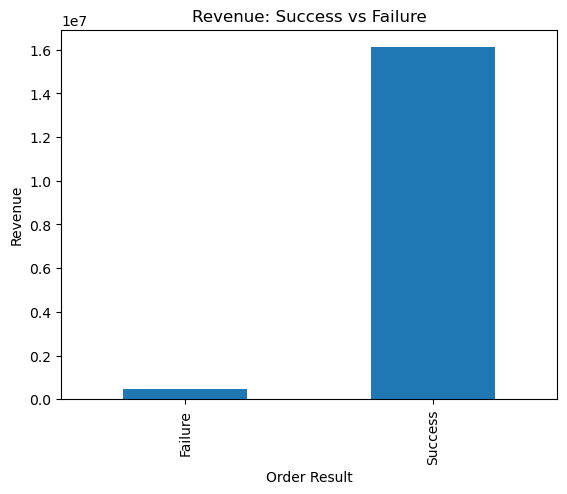

In [40]:

order_df['order_result'] = order_df['order_status'].apply(
    lambda x: 'Success' if x == 'delivered' else 'Failure'
)

status_revenue = order_df.groupby('order_result')['revenue'].sum()

status_revenue.plot(kind='bar')
plt.title("Revenue: Success vs Failure")
plt.xlabel("Order Result")
plt.ylabel("Revenue")
plt.show()



In [ ]:
"""
KEY INSIGHT:

- Majority of revenue (~97%) comes from successfully delivered orders
- However, failed orders still contribute to a loss of ~₹4.5 Lakhs
- This highlights that even a small failure rate results in significant financial impact

BUSINESS TAKEAWAY:

Reducing failures by even a small percentage can recover substantial revenue
"""

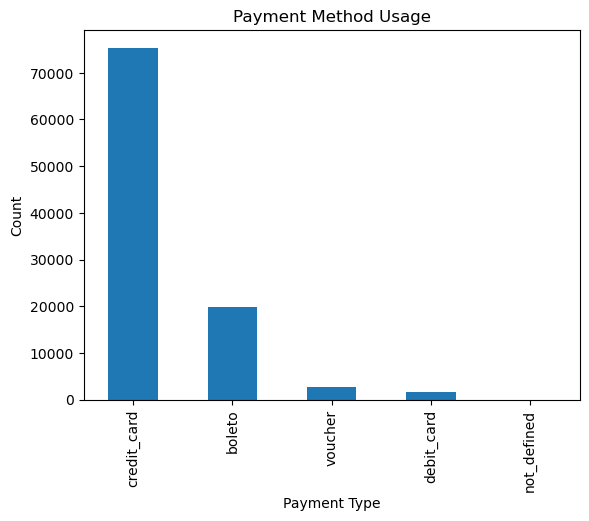

In [41]:
order_df['payment_type'].value_counts().plot(kind='bar')
plt.title("Payment Method Usage")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

In [ ]:
"""
KEY INSIGHT:

- Credit card is the most widely used payment method (~75% of transactions)
- It also contributes to ~75% of total revenue loss
- This indicates that high usage combined with even small failure rates
  leads to significant financial impact

BUSINESS INTERPRETATION:

Since most users rely on credit cards, any inefficiency in this payment method
directly affects overall revenue

RECOMMENDATION:

Prioritize optimization of credit card payment processing
"""

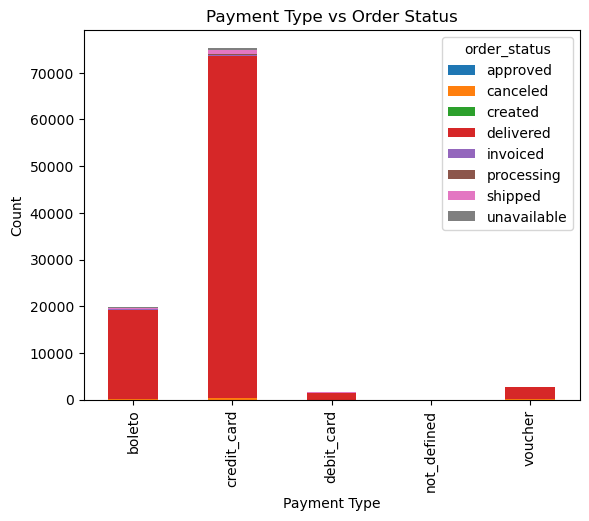

In [42]:
pd.crosstab(order_df['payment_type'], order_df['order_status']).plot(kind='bar', stacked=True)

plt.title("Payment Type vs Order Status")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

In [ ]:
"""
KEY INSIGHT:

- Credit card dominates both usage and failure contribution
- While the success rate is high, its massive usage volume makes it
  the largest contributor to revenue loss

- Other payment methods have lower usage and therefore lower impact
  on overall revenue loss

BUSINESS CONCLUSION:

The issue is not just failure rate — it is failure rate × usage volume

RECOMMENDATION:

Focus on optimizing high-volume payment methods (credit card)
rather than low-impact methods
"""

In [ ]:
"""
FINAL BUSINESS INSIGHTS

1. ORDER PERFORMANCE

- Approximately 97% of orders are successfully delivered
- Around 3% of orders fail (cancelled, unavailable, etc.)
- Despite a high success rate, failures still lead to measurable revenue loss

---

2. REVENUE IMPACT

- Total revenue loss is approximately ₹4.5 Lakhs
- This accounts for ~2.7% of total revenue
- Even a small percentage of failed orders results in significant financial impact

---

3. PAYMENT METHOD INSIGHTS

- Credit card is the most widely used payment method (~75% of transactions)
- It contributes ~75% of total revenue loss

- Boleto contributes ~16% of revenue loss
- Other payment methods (voucher, debit card) have minimal impact

---

4. ROOT CAUSE ANALYSIS

- Revenue loss is driven by:
  
  Failure Rate × Usage Volume

- Credit card dominates both usage and failure contribution
- Small inefficiencies in high-usage payment methods lead to large losses

---

5. BUSINESS RISK

- Heavy dependency on credit card payments
- Any issues in this method directly impact overall revenue
- Indicates potential problems in:
  - Payment gateway reliability
  - Transaction failures
  - Authorization/processing delays
"""

In [ ]:
"""
BUSINESS RECOMMENDATIONS

1. OPTIMIZE CREDIT CARD PAYMENTS (HIGHEST PRIORITY)

- Improve payment gateway reliability
- Reduce transaction failure rates
- Monitor credit card failures in real-time

---

2. IMPLEMENT RETRY MECHANISMS

- Allow users to retry failed transactions easily
- Reduce drop-offs due to temporary failures

---

3. ENABLE FALLBACK PAYMENT OPTIONS

- Suggest alternative payment methods when credit card fails
- Reduce complete order abandonment

---

4. IMPROVE PAYMENT SUCCESS TRACKING

- Build dashboards to monitor failure rates by payment type
- Identify issues early and act quickly

---

5. REDUCE DEPENDENCY ON SINGLE PAYMENT METHOD

- Encourage usage of alternative payment options
- Balance risk across multiple payment channels

---

EXPECTED IMPACT

- Reducing failures by 1–2% can recover lakhs in revenue
- Improved customer experience and higher conversion rates
- More stable and reliable payment ecosystem
"""

In [45]:
order_df.to_csv("final_dataset.csv", index=False)